In [37]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator,RegularGridInterpolator

atom_pos = [3.17410101, 3.17410101, 2.06394376]
# atom_pos = [2.09770314,2.09770314,2.09770314]

r_max = 1.4

# Load your unsorted data
data = np.loadtxt('chg_afm2.txt')
x = data[:, 0] - atom_pos[0]
y = data[:, 1] - atom_pos[1]
z = data[:, 2] - atom_pos[2]
w = data[:, 3]

points = np.column_stack((x, y, z))
unique_points, unique_indices = np.unique(points, axis=0, return_index=True)

w_unique = w[unique_indices]
x_unique = np.unique(x)
y_unique = np.unique(y)
z_unique = np.unique(z)
x_spacing = np.diff(x_unique)
y_spacing = np.diff(y_unique)
z_spacing = np.diff(z_unique)
nx, ny, nz = len(x_unique), len(y_unique), len(z_unique)
expected = nx* ny*nz

if expected == len(w_unique):
    irregular = False
else: irregular = True

# assert False
# Combine coordinates into points array
points = np.column_stack((x, y, z))

# Create the interpolator for scattered data
if irregular == True:
    
    interpolator = LinearNDInterpolator(points, w)
else:
    w_3d = w.reshape(nx, ny, nz)
    interpolator = RegularGridInterpolator(
        (x_unique, y_unique, z_unique),
        w_3d,
        method='linear',  # 'linear', 'nearest', or 'cubic'
        bounds_error=False,
        fill_value=0.0
    )
    
# Define spherical coordinates
num_r = 50
num_theta = 30
num_phi = 50
offset = 0.2
r_ls = np.linspace(r_max/num_r, r_max, num_r)
theta_ls = np.linspace(1/num_theta, np.pi*(1-1/num_theta), num_theta)
phi_ls = np.linspace(0, 2*np.pi*(1-1/num_phi), num_phi)
r_grid = [[0,0]]
grid_points = [[0,0,0]]
for r in r_ls:
    for theta in theta_ls:
        for phi in phi_ls:
            r_grid.append([r,theta])
            grid_points.append([r*np.sin(theta)*np.cos(phi),r*np.sin(theta)*np.sin(phi),r*np.cos(theta)])
grid_points = np.array(grid_points)
r_grid = np.array(r_grid)

# Interpolate weights onto the regular grid
w_regular_flat = interpolator(grid_points)
# print(w_regular_flat)

# # Reshape back to 3D grid
# w_regular = w_regular_flat.reshape(grid_size, grid_size, grid_size)

# # Optional: Handle NaN values (points outside convex hull)
# # You can replace NaN with 0 or nearest neighbor value
# w_regular = np.nan_to_num(w_regular_flat, nan=0.0)  # Replace NaN with 0

# # Now w_regular is your 20x20x20 regular grid of interpolated weights
# print(f"Regular grid shape: {w_regular.shape}")
print(f"Number of interpolated points: {np.sum(~np.isnan(w_regular_flat))}, Expected: {len(grid_points)}")

# # Optional: Save the regular grid to a file
# np.savetxt('regular_grid.txt', w_regular.reshape(-1, 1))

Number of interpolated points: 75001, Expected: 75001


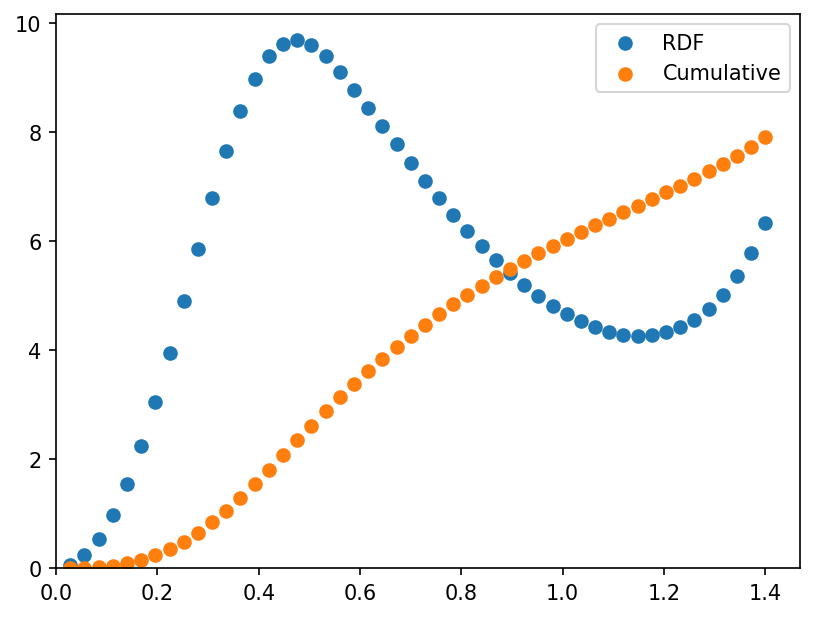

In [38]:
import matplotlib.pyplot as plt
x = grid_points[:,0]
y = grid_points[:,1]
z = grid_points[:,2]
w = w_regular_flat*6.748

plot_data = []
cumulative = []
theta_diff = theta_ls[1]-theta_ls[0]
phi_diff = phi_ls[1]-phi_ls[0]
r_diff = r_ls[1]-r_ls[0]
for r in r_ls:
    val = 0
    for theta in theta_ls:
        
        val = val + np.sum(w[(r_grid[:,0]==r)*(r_grid[:,1]==theta)])*(r)**2*np.sin(theta)*theta_diff*phi_diff
    plot_data.append([r,val])
    cumulative.append(np.sum(np.array(plot_data)[:,1])*r_diff)
plot_data = np.array(plot_data)
plt.figure(dpi=150)
plt.scatter(plot_data[:,0],plot_data[:,1],label='RDF')
plt.scatter(plot_data[:,0],cumulative,label='Cumulative')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()

In [39]:
np.savetxt('afm2_radial.dat',np.column_stack((plot_data,cumulative)))